In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
df = pd.read_csv("NFCS 2024 State Data 250623.csv")
df.head(10)

,NFCSID,STATEQ,CENSUSDIV,CENSUSREG,A50A,A3Ar_w,A50B,A4A_new_w,A5_2015,A6,...,M6,M7,M8,M31,M50,M9,M10,wgt_n2,wgt_d2,wgt_s3
0,2024010001,36,3,2,2,3,9,1,6,1,...,1,3,98,98,98,1,2,1.153548,1.123949,0.859644
1,2024010002,48,9,4,1,6,6,1,5,5,...,1,3,98,3,3,1,2,1.398688,0.863440,0.975078
2,2024010003,38,9,4,1,6,6,1,4,1,...,1,3,1,98,98,2,2,1.398688,0.472645,0.893974
3,2024010004,48,9,4,2,6,12,1,7,1,...,1,3,1,4,98,1,2,1.250293,0.614156,0.778748
4,2024010005,44,7,3,2,6,12,2,7,4,...,1,3,2,3,2,1,1,1.250076,2.228957,0.783507
5,2024010006,3,8,4,2,4,10,1,6,2,...,1,3,2,3,1,1,2,0.359551,1.851883,0.861736
6,2024010007,11,5,3,1,4,4,2,5,2,...,1,1,98,98,98,98,2,1.075989,1.348475,0.886610
7,2024010008,39,2,1,2,2,8,2,2,2,...,1,2,4,2,2,1,98,2.934629,1.749106,1.621238
8,2024010009,29,8,4,2,5,11,1,4,4,...,2,3,98,4,98,98,98,0.464731,1.016115,1.107401
9,2024010010,44,7,3,2,5,11,1,4,5,...,1,3,2,2,98,1,2,1.488421,3.003482,1.039432


# **Exploratory Data Analysis**


Financial Confidence Variable: M4

Financial Competence Variables: M6, M7, M8, M9, M10 (Big Five)

In [56]:
# Data Cleaning (handle NaNs, repeated rows, outliers, non-respondees)
# Note: 98 = Don't know, 99 = Prefer not to say
# For M4, filter out 98 and 99. For M6-10, treat it as an incorrect
# This is because everyone is assumed to be able to self-report their confidence

# Check for nulls and spaces
cols = ['M4','M6','M7','M8','M9','M10']
for i in cols:
  print(((df[i] == ' ') | (df[i].isna())).sum())

0
0
0
0
0
0


In [57]:
# Check for duplicate rows
df[df.duplicated(keep=False)].sum()

,0
NFCSID,0
STATEQ,0
CENSUSDIV,0
CENSUSREG,0
A50A,0
...,...
M9,0
M10,0
wgt_n2,0.0
wgt_d2,0.0


In [58]:
# Create a binary confidence column
df['Confidence'] = df['M4'].apply(lambda i: 0 if i <= 5 else 1)
print(((df['Confidence'] == 0).sum()) == (df['M4'].between(1, 5).sum()))
print(((df['Confidence'] == 1).sum()) == (df['M4'].between(6, 7).sum()))

True
False


In [59]:
# Filter out those who can't self-report confidence
df = df[(df['M4'] != 98) & (df['M4'] != 99)]
df['M4'].value_counts()

,count
M4,
5,7986
6,5559
4,5033
7,3124
3,1937
2,750
1,641


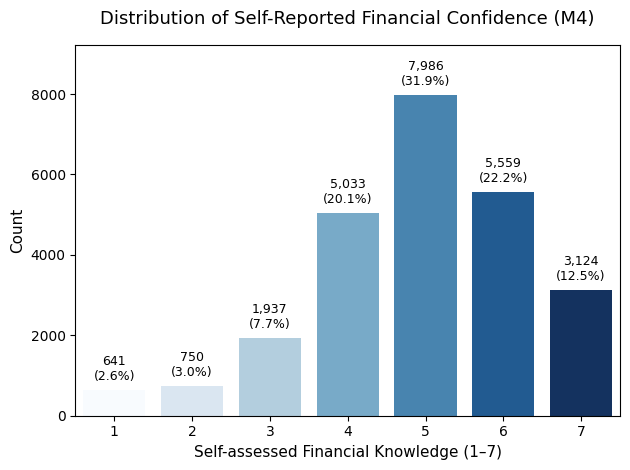

Low Confidence (1–5): 16,347 respondents (65.3%)
High Confidence (6–7): 8,683 respondents (34.7%)


In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Threshold segmentation ---
threshold = 5
df['Confidence'] = (df['M4'] > threshold).astype(int)

# --- Count plot (new syntax for Seaborn ≥0.14) ---
ax = sns.countplot(data=df, x='M4', hue='M4', palette='Blues', legend=False)  # <-- key fix

plt.title('Distribution of Self-Reported Financial Confidence (M4)', fontsize=13, pad=15)
plt.xlabel('Self-assessed Financial Knowledge (1–7)', fontsize=11)
plt.ylabel('Count', fontsize=11)

# --- Add counts + percentages above bars ---
total = len(df)
for p in ax.patches:
    height = p.get_height()
    percent = 100 * height / total
    ax.annotate(f"{int(height):,}\n({percent:.1f}%)",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points',
                fontsize=9)

# --- Add extra space on top so labels fit ---
ax.set_ylim(0, ax.get_ylim()[1] * 1.10)
plt.tight_layout()
plt.show()

# --- Print summary of groups ---
group = df['Confidence'].value_counts().sort_index()
print(f"Low Confidence (1–5): {group[0]:,} respondents ({group[0]/total*100:.1f}%)")
print(f"High Confidence (6–7): {group[1]:,} respondents ({group[1]/total*100:.1f}%)")



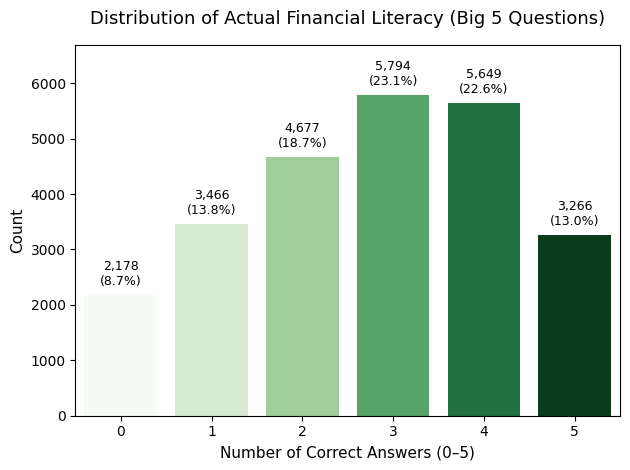

Low Literacy (0–3 correct): 16,115 respondents (64.4%)
High Literacy (4–5 correct): 8,915 respondents (35.6%)


In [61]:
# Correct answers
correct_answers = {'M6': 1, 'M7': 3, 'M8': 2, 'M9': 1, 'M10': 2}

# Compute literacy score (0–5)
df['Literacy_Score'] = sum(df[col] == ans for col, ans in correct_answers.items())

# Threshold segmentation (Low vs. High literacy)
threshold_lit = 3  # ≤3 = low, ≥4 = high
df['Literacy_Level'] = (df['Literacy_Score'] > threshold_lit).astype(int)

import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(data=df, x='Literacy_Score', hue='Literacy_Score', palette='Greens', legend=False)
plt.title('Distribution of Actual Financial Literacy (Big 5 Questions)', fontsize=13, pad=15)
plt.xlabel('Number of Correct Answers (0–5)', fontsize=11)
plt.ylabel('Count', fontsize=11)

total = len(df)
for p in ax.patches:
    height = p.get_height()
    percent = 100 * height / total
    ax.annotate(f"{int(height):,}\n({percent:.1f}%)",
                (p.get_x() + p.get_width()/2., height),
                ha='center', va='bottom', xytext=(0, 5),
                textcoords='offset points', fontsize=9)

ax.set_ylim(0, ax.get_ylim()[1]*1.10)
plt.tight_layout()
plt.show()

# Print summary of low vs high literacy
lit_counts = df['Literacy_Level'].value_counts().sort_index()
low, high = lit_counts[0], lit_counts[1]
low_pct, high_pct = low/total*100, high/total*100
print(f"Low Literacy (0–3 correct): {low:,} respondents ({low_pct:.1f}%)")
print(f"High Literacy (4–5 correct): {high:,} respondents ({high_pct:.1f}%)")

#if we considered 0–2 vs 3–5, the distribution is evenly 43.8 and 56.2, but scoring 3 means a respondent still missed 40 % of the questions.
#Using 4–5 as the high-literacy group better captures those who truly master the material, keeps the split consistent with our confidence classification, and matches prior NFCS literature that defines ‘high financial literacy’ as answering four or more questions correctly.

In [62]:
# Judge financial literacy and create a binary competence column
scores = {'M6':1,'M7':3,'M8':2,'M9':1,'M10':2}
df['Competence Score'] = sum(df[col] == value for col, value in scores.items())

df['Competence'] = df['Competence Score'].apply(lambda i: 0 if i <= 3 else 1)
print(((df['Competence'] == 0).sum()) == (df['Competence Score'].between(0, 3).sum()))
print(((df['Competence'] == 1).sum()) == (df['Competence Score'].between(4, 5).sum()))

True
True


# **Data Visualization**

In [63]:
# Create 2x2 confusion matrix of predicted financial knowledge vs actual knowledge
# For confidence: 1-5 = Low confidence, 6-7 = High confidence
# For competence: 0-3 = Low competence, 4-5 = High competence

confusionMatrix = pd.crosstab(df['Confidence'],df['Competence'])
print(confusionMatrix)

Competence      0     1
Confidence             
0           11649  4698
1            4466  4217


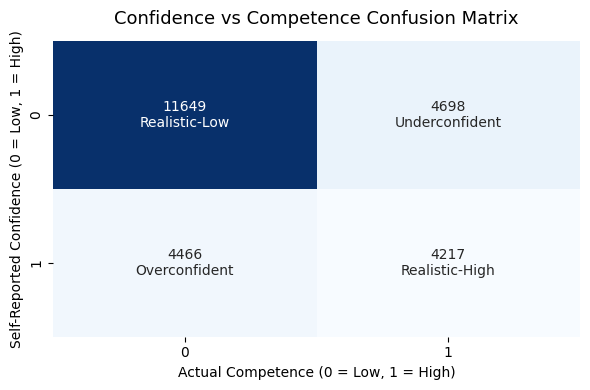

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Compute confusion matrix
conf_mat = pd.crosstab(df['Confidence'], df['Competence'])

# Create annotation labels with quadrant names + counts
annot_labels = conf_mat.copy().astype(str)

annot_labels.loc[0,0] = f"{conf_mat.loc[0,0]}\nRealistic-Low"
annot_labels.loc[0,1] = f"{conf_mat.loc[0,1]}\nUnderconfident"
annot_labels.loc[1,0] = f"{conf_mat.loc[1,0]}\nOverconfident"
annot_labels.loc[1,1] = f"{conf_mat.loc[1,1]}\nRealistic-High"

plt.figure(figsize=(6,4))
sns.heatmap(
    conf_mat,
    annot=annot_labels,
    fmt='',
    cmap='Blues',
    cbar=False
)

plt.title('Confidence vs Competence Confusion Matrix', fontsize=13, pad=12)
plt.xlabel('Actual Competence (0 = Low, 1 = High)')
plt.ylabel('Self-Reported Confidence (0 = Low, 1 = High)')
plt.tight_layout()
plt.show()

In [66]:
# Create quadrant variable
def define_quadrant(row):
    if row['Confidence'] == 0 and row['Competence'] == 0:
        return 'Realistic-Low'
    elif row['Confidence'] == 0 and row['Competence'] == 1:
        return 'Underconfident'
    elif row['Confidence'] == 1 and row['Competence'] == 0:
        return 'Overconfident'
    else:
        return 'Realistic-High'

df['Quadrant'] = df.apply(define_quadrant, axis=1)

/tmp/ipykernel_6457/3351317989.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


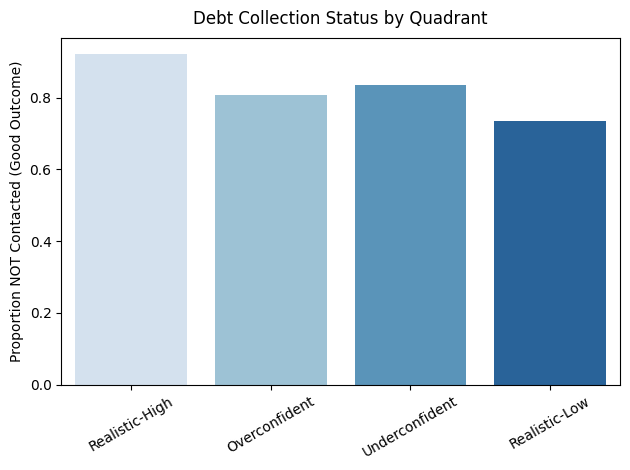

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Clean G38: drop 98/99 ---
df['G38_clean'] = df['G38'].replace({98: np.nan, 99: np.nan})

# --- Recode to 0 = bad, 1 = good ---
# 1 = contacted → BAD → 0
# 2 = not contacted → GOOD → 1
df['Debt_Good'] = df['G38_clean'].replace({1: 0, 2: 1})

# --- Visualization ---
sns.barplot(
    data=df,
    x='Quadrant',
    y='Debt_Good',
    estimator='mean',
    errorbar=None,
    palette="Blues"
)

plt.title('Debt Collection Status by Quadrant', fontsize=12, pad=10)
plt.ylabel('Proportion NOT Contacted (Good Outcome)')
plt.xlabel('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


/tmp/ipykernel_6457/1881371756.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


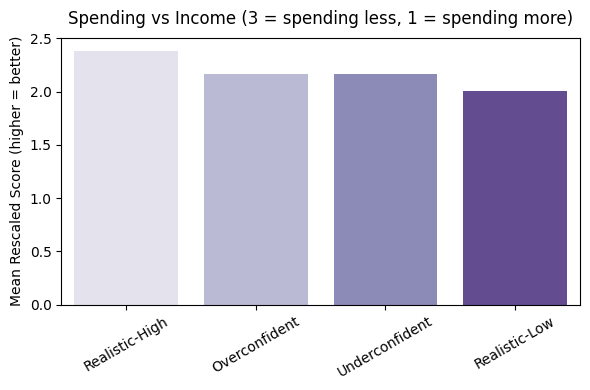

/tmp/ipykernel_6457/1881371756.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


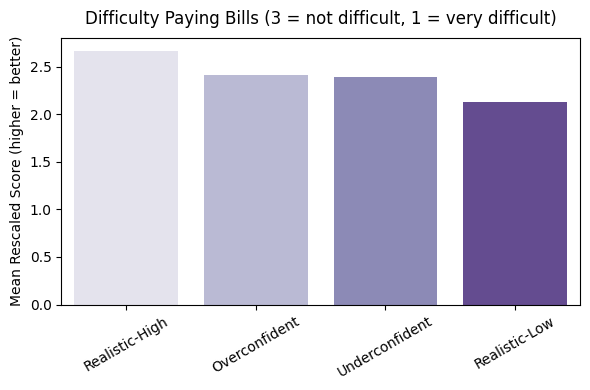

/tmp/ipykernel_6457/1881371756.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


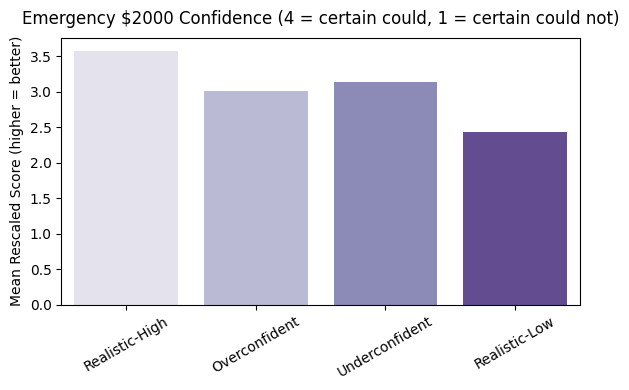

/tmp/ipykernel_6457/1881371756.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


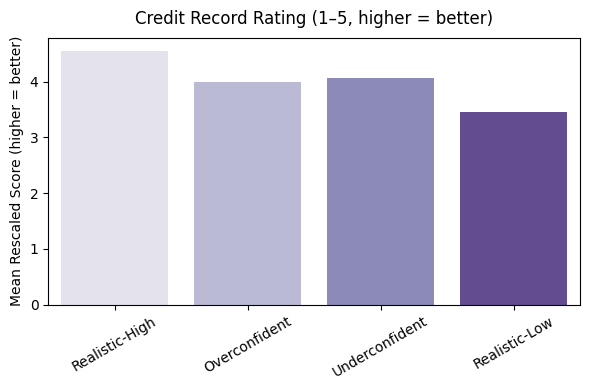

In [68]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1. Recode each variable
# -----------------------------

# J3: Spending vs income
# 1 = less than income  → 3 (best)
# 2 = more than income  → 1 (worst)
# 3 = about equal       → 2
df['J3_new'] = df['J3'].map({
    1: 3,
    2: 1,
    3: 2,
    98: np.nan,
    99: np.nan
})

# J4: Difficulty paying bills
# 1 = very difficult    → 1 (worst)
# 2 = somewhat          → 2
# 3 = not at all        → 3 (best)
df['J4_new'] = df['J4'].map({
    1: 1,
    2: 2,
    3: 3,
    98: np.nan,
    99: np.nan
})

# J20: Emergency $2000 confidence
# 1 = certain could     → 4 (best)
# 2 = probably could    → 3
# 3 = probably not      → 2
# 4 = certain could not → 1 (worst)
df['J20_new'] = df['J20'].map({
    1: 4,
    2: 3,
    3: 2,
    4: 1,
    98: np.nan,
    99: np.nan
})

# J32: Credit record rating
# keep original 1–5 order, just drop 98/99
df['J32_new'] = df['J32'].map({
    1: 1,
    2: 2,
    3: 3,
    4: 4,
    5: 5,
    98: np.nan,
    99: np.nan
})

# -----------------------------
# 2. Bar charts by Quadrant
#    (higher = better)
# -----------------------------

ordinal_vars = ['J3_new', 'J4_new', 'J20_new', 'J32_new']
titles = {
    'J3_new':  'Spending vs Income (3 = spending less, 1 = spending more)',
    'J4_new':  'Difficulty Paying Bills (3 = not difficult, 1 = very difficult)',
    'J20_new': 'Emergency $2000 Confidence (4 = certain could, 1 = certain could not)',
    'J32_new': 'Credit Record Rating (1–5, higher = better)'
}

for var in ordinal_vars:
    plt.figure(figsize=(6,4))
    sns.barplot(
        data=df,
        x='Quadrant',
        y=var,
        errorbar=None,  # replaces deprecated ci=None
        palette="Purples"
    )
    plt.title(titles[var], fontsize=12, pad=10)
    plt.ylabel('Mean Rescaled Score (higher = better)')
    plt.xlabel('')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()



/tmp/ipykernel_6457/1392656376.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


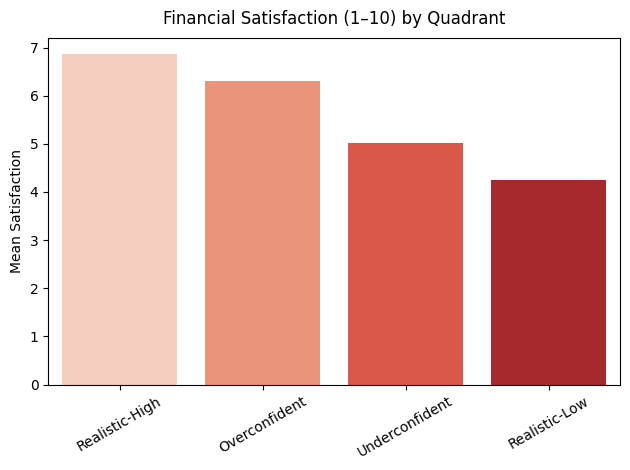

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Clean J1 (drop 98 and 99) ---
df['J1_clean'] = df['J1'].replace({98: np.nan, 99: np.nan})

# --- Visualization ---
sns.barplot(
    data=df,
    x='Quadrant',
    y='J1_clean',
    errorbar=None,
    palette="Reds"
)

plt.title('Financial Satisfaction (1–10) by Quadrant', fontsize=12, pad=10)
plt.ylabel('Mean Satisfaction')
plt.xlabel('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6457/2670686491.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


NameError: name 'pivot' is not defined

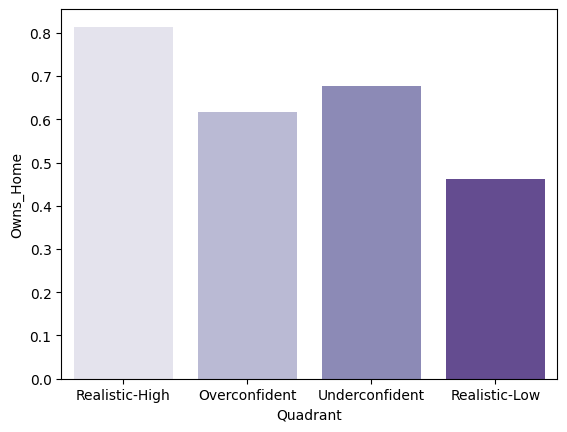

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Clean Ea_1 (Home ownership) responses ---
# 1 = Yes, 2 = No, 98/99 = Don't know / Prefer not to say
df['EA_1_clean'] = df['EA_1'].replace({98: np.nan, 99: np.nan})

# Recode: Yes = 1, No = 0
df['Owns_Home'] = df['EA_1_clean'].replace({1: 1, 2: 0})

# --- Visualization ---
sns.barplot(
    data=df,
    x='Quadrant',
    y='Owns_Home',
    estimator='mean',
    errorbar=None,
    palette="Purples"
)
quad_order = ['Realistic-High', 'Overconfident', 'Underconfident', 'Realistic-Low']
pivot = pivot.reindex(quad_order)


plt.title('Home Ownership by Confidence–Competence Quadrant', fontsize=12, pad=10)
plt.ylabel('Proportion Owning a Home (1 = Yes, 0 = No)')
plt.xlabel('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


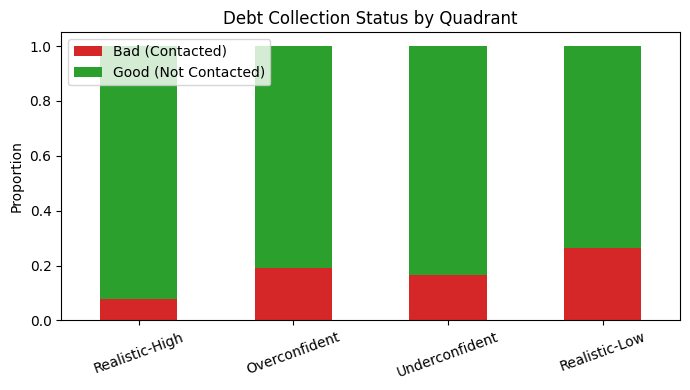

In [79]:
quad_order = ['Realistic-High', 'Overconfident', 'Underconfident', 'Realistic-Low']

debt_prop = (
    df.groupby('Quadrant')['Debt_Good']
      .value_counts(normalize=True)
      .rename('proportion')
      .reset_index()
)

pivot = debt_prop.pivot(index='Quadrant', columns='Debt_Good', values='proportion')

pivot = pivot.rename(columns={0: 'Bad (Contacted)', 1: 'Good (Not Contacted)'})

# Reorder quadrants according to your preferred sequence
pivot = pivot.reindex(quad_order)

pivot.plot(kind='bar', stacked=True, figsize=(7,4), color=['#d62728', '#2ca02c'])

plt.title("Debt Collection Status by Quadrant")
plt.ylabel("Proportion")
plt.xlabel("")
plt.legend(title="", loc="upper left")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

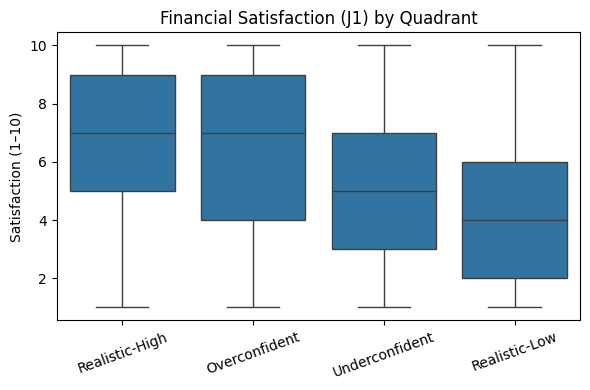

In [80]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Quadrant', y='J1_clean')
plt.title("Financial Satisfaction (J1) by Quadrant")
plt.xlabel("")
plt.ylabel("Satisfaction (1–10)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


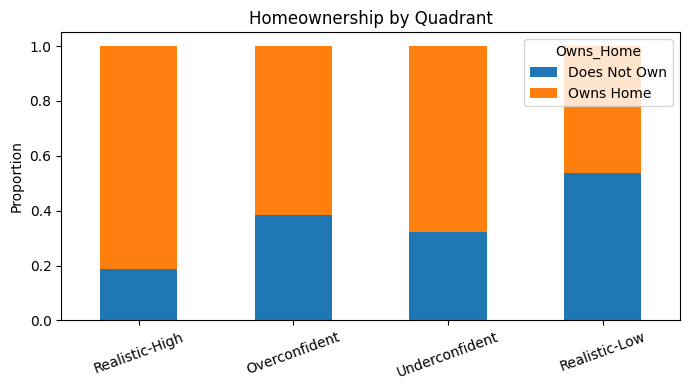

In [81]:
home_prop = (
    df.groupby('Quadrant')['Owns_Home']
      .value_counts(normalize=True)
      .rename('proportion')
      .reset_index()
)


pivot = home_prop.pivot(index='Quadrant', columns='Owns_Home', values='proportion')
pivot = pivot.rename(columns={0: 'Does Not Own', 1: 'Owns Home'})

quad_order = ['Realistic-High', 'Overconfident', 'Underconfident', 'Realistic-Low']
pivot = pivot.reindex(quad_order)


pivot.plot(kind='bar', stacked=True, figsize=(7,4), color=['#1f77b4', '#ff7f0e'])
plt.title("Homeownership by Quadrant")
plt.ylabel("Proportion")
plt.xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

=== Normalized Scores by Quadrant ===
                J1_clean  J3_new  J4_new  J20_new  J32_new  Owns_Home  \
Quadrant                                                                
Realistic-High     1.000    1.00   1.000    1.000    1.000      1.000   
Overconfident      0.785    0.42   0.530    0.509    0.493      0.437   
Underconfident     0.296    0.41   0.489    0.615    0.552      0.609   
Realistic-Low      0.000    0.00   0.000    0.000    0.000      0.000   

                Debt_Good  Final_Score  
Quadrant                                
Realistic-High      1.000        1.000  
Overconfident       0.390        0.509  
Underconfident      0.536        0.501  
Realistic-Low       0.000        0.000  


/tmp/ipykernel_6457/3888244415.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


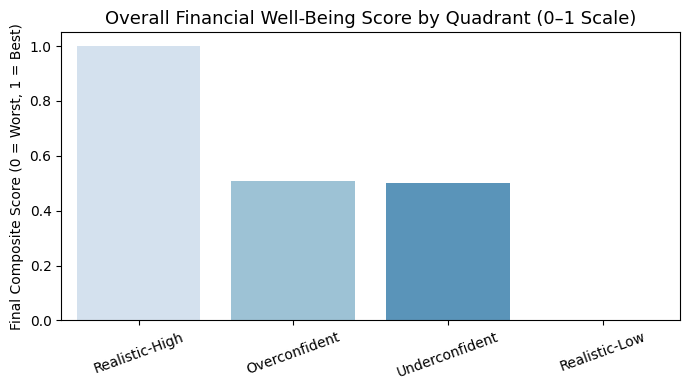

In [75]:
import numpy as np
import pandas as pd

# -----------------------
# 1. Variables to include
# -----------------------
metrics = ['J1_clean', 'J3_new', 'J4_new', 'J20_new', 'J32_new',
           'Owns_Home', 'Debt_Good']

# ensure quadrant order
quad_order = ['Realistic-High', 'Overconfident', 'Underconfident', 'Realistic-Low']

# -----------------------
# 2. Compute means by quadrant
# -----------------------
means_raw = df.groupby('Quadrant')[metrics].mean().reindex(quad_order)

# -----------------------
# 3. Min–max normalize each metric (column-wise)
# -----------------------
def minmax(col):
    if col.max() == col.min():
        return col * 0   # avoid divide-by-zero
    return (col - col.min()) / (col.max() - col.min())

means_norm = means_raw.apply(minmax, axis=0)

# -----------------------
# 4. Compute final composite score
# -----------------------
means_norm['Final_Score'] = means_norm.mean(axis=1)

print("=== Normalized Scores by Quadrant ===")
print(means_norm.round(3))

# -----------------------
# 5. Visualization (bar chart of final scores)
# -----------------------
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,4))
sns.barplot(
    x=means_norm.index,
    y=means_norm['Final_Score'],
    palette='Blues'
)

plt.title("Overall Financial Well-Being Score by Quadrant (0–1 Scale)", fontsize=13)
plt.ylabel("Final Composite Score (0 = Worst, 1 = Best)")
plt.xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


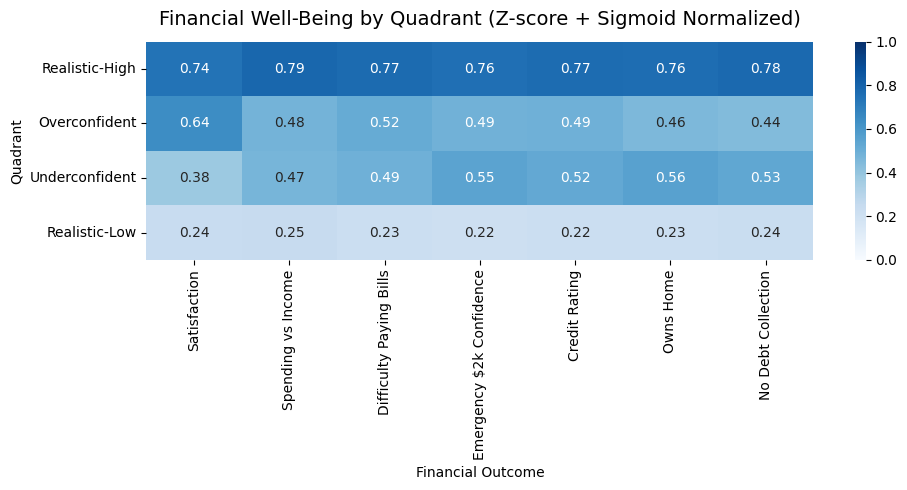

In [76]:
# -------------------------------------------
# 1. Rename columns FIRST (important!)
# -------------------------------------------

col_labels = {
    'J1_clean':   'Satisfaction',
    'J3_new':     'Spending vs Income',
    'J4_new':     'Difficulty Paying Bills',
    'J20_new':    'Emergency $2k Confidence',
    'J32_new':    'Credit Rating',
    'Owns_Home':  'Owns Home',
    'Debt_Good':  'No Debt Collection'
}

means_raw = means_raw.rename(columns=col_labels)


# -------------------------------------------
# 2. Method 3: Z-score + Sigmoid Normalization
# -------------------------------------------

def zscore(col):
    if col.std() == 0:
        return col * 0
    return (col - col.mean()) / col.std()

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Apply normalization
z = means_raw.apply(zscore, axis=0)
heat_sigmoid = z.apply(sigmoid, axis=0)  # all values strictly between 0 and 1


# -------------------------------------------
# 3. Heatmap (values match colors)
# -------------------------------------------

plt.figure(figsize=(10, 5))
sns.heatmap(
    heat_sigmoid,
    annot=heat_sigmoid.round(2),   # show normalized numbers
    fmt=".2f",
    cmap="Blues",
    vmin=0, vmax=1,
    cbar=True
)

plt.title("Financial Well-Being by Quadrant (Z-score + Sigmoid Normalized)", fontsize=14, pad=12)
plt.xlabel("Financial Outcome")
plt.ylabel("Quadrant")
plt.tight_layout()
plt.show()


# **Predictive Analysis**

In [82]:
import numpy as np
import pandas as pd

conf_behavior_cols = ['J3', 'J4', 'J20', 'J32', 'J63']
comp_behavior_cols = ['J3', 'J4', 'J20', 'J5', 'J8']
X = df[conf_behavior_cols].copy()

for c in conf_behavior_cols:
    X[c] = pd.to_numeric(X[c], errors='coerce')

# treat 98/99 as missing
X = X.replace({98: np.nan, 99: np.nan})

# fill missing with column medians
X = X.fillna(X.median())

=== Confidence prediction ===
              precision    recall  f1-score   support

           0       0.77      0.64      0.70      3269
           1       0.48      0.64      0.55      1737

    accuracy                           0.64      5006
   macro avg       0.62      0.64      0.62      5006
weighted avg       0.67      0.64      0.64      5006



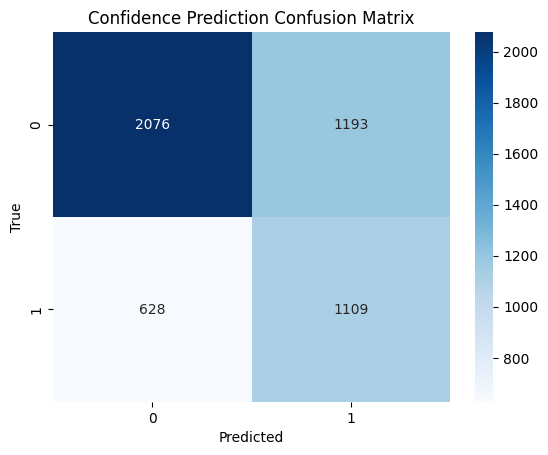

,feature,importance
2,J20,0.281853
3,J32,0.276176
4,J63,0.212618
1,J4,0.145893
0,J3,0.083460


In [83]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_conf = df['Confidence']   # 0 = low, 1 = high

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y_conf, test_size=0.2, random_state=42, stratify=y_conf
)


rf_conf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight='balanced'
)

rf_conf.fit(Xc_train, yc_train)


yc_pred = rf_conf.predict(Xc_test)

print("=== Confidence prediction ===")
print(classification_report(yc_test, yc_pred))

cm_conf = confusion_matrix(yc_test, yc_pred)
sns.heatmap(cm_conf, annot=True, fmt='d', cmap='Blues')
plt.title("Confidence Prediction Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

importances_conf = pd.DataFrame({
    'feature': conf_behavior_cols,
    'importance': rf_conf.feature_importances_
}).sort_values('importance', ascending=False)

importances_conf.head(10)

=== Competence prediction ===
              precision    recall  f1-score   support

           0       0.77      0.70      0.73      3223
           1       0.54      0.63      0.58      1783

    accuracy                           0.67      5006
   macro avg       0.66      0.67      0.66      5006
weighted avg       0.69      0.67      0.68      5006



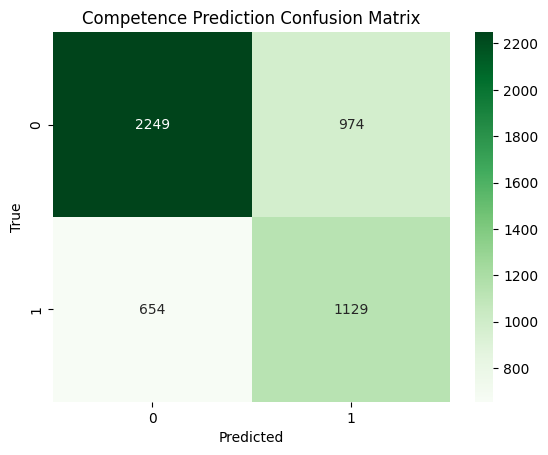

,feature,importance
2,J20,0.332114
3,J5,0.303859
4,J8,0.175810
1,J4,0.109551
0,J3,0.078665


In [86]:
y_comp = df['Competence']   # 0 = low, 1 = high

Xk_train, Xk_test, yk_train, yk_test = train_test_split(
    X, y_comp, test_size=0.2, random_state=42, stratify=y_comp
)
rf_comp = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight='balanced'
)

rf_comp.fit(Xk_train, yk_train)
yk_pred = rf_comp.predict(Xk_test)

print("=== Competence prediction ===")
print(classification_report(yk_test, yk_pred))

cm_comp = confusion_matrix(yk_test, yk_pred)
sns.heatmap(cm_comp, annot=True, fmt='d', cmap='Greens')
plt.title("Competence Prediction Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
importances_comp = pd.DataFrame({
    'feature': comp_behavior_cols,
    'importance': rf_comp.feature_importances_
}).sort_values('importance', ascending=False)

importances_comp.head(10)

/tmp/ipykernel_6457/2625953548.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


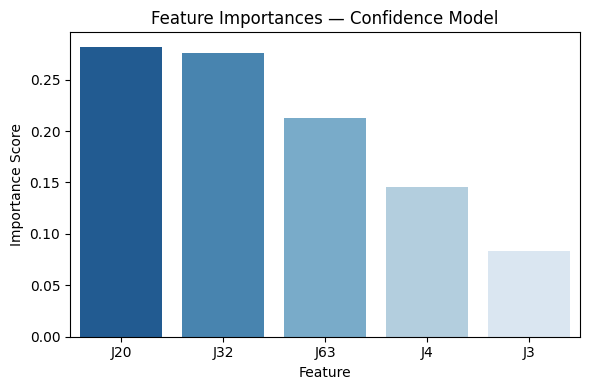

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dataframe for confidence model importances
feat_imp_conf = pd.DataFrame({
    'Feature': conf_behavior_cols,
    'Importance': rf_conf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(
    data=feat_imp_conf,
    x='Feature',
    y='Importance',
    palette='Blues_r'
)
plt.title("Feature Importances — Confidence Model")
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()


/tmp/ipykernel_6457/281229545.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


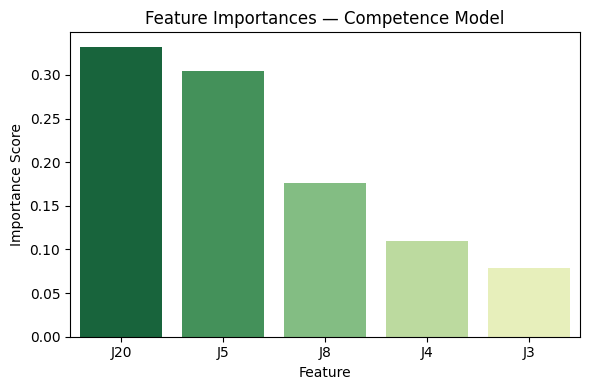

In [87]:
# Dataframe for competence model importances
feat_imp_comp = pd.DataFrame({
    'Feature': comp_behavior_cols,
    'Importance': rf_comp.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(
    data=feat_imp_comp,
    x='Feature',
    y='Importance',
    palette='YlGn_r'
)
plt.title("Feature Importances — Competence Model")
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()